<a href="https://colab.research.google.com/github/elkanajnrmanullang/UTS_DataMining/blob/elkanajnrmanullang/DataMining_MissingValues_Kelompok1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Data Penumpang Titanic: Dari Penanganan Missing Value hingga Penentuan Fitur Paling Berpengaruh
Aggota Kelompok :
1.   Elkana Juanro Manullang		122140168
2.   Rachel Olivia Manullang		122140181
3.   Martua Kevin A.M.H.Lubis	  122140119

Dataset : Dataset.csv

# **Pendahuluan**
Laporan ini menyajikan analisis komprehensif terhadap dataset penumpang Titanic dengan tujuan utama untuk mengidentifikasi faktor-faktor (fitur) yang paling signifikan dalam menentukan tingkat kelangsungan hidup (Survived). Analisis ini mencakup dua tahap utama: pertama, penanganan data yang hilang (missing value) untuk memastikan kualitas data, dan kedua, analisis mendalam untuk mengukur dan memeringkat pengaruh setiap fitur terhadap hasil akhir

# **Masalah**
Analisis awal pada dataset train.csv menunjukkan adanya data yang hilang pada beberapa kolom krusial. Masalah utama adalah bagaimana cara menangani data yang hilang ini secara efektif tanpa merusak integritas dan mengurangi ukuran dataset secara drastis.

#**Tahap 1: Persiapan Lingkungan Kerja dan Eksplorasi Data Awal**
Kode di bawah ini akan memuat library yang dibutuhkan, memuat dataset train.csv
1. Setup Library: Kode pertama mengimpor library yang akan kita gunakan. Pandas adalah "meja kerja" utama kita untuk mengelola data dalam bentuk tabel (DataFrame). NumPy menyediakan dukungan untuk operasi matematika yang efisien. Matplotlib dan Seaborn adalah "alat lukis" kita untuk membuat berbagai jenis grafik dan visualisasi data.
2. Load Data: Selanjutnya, kita memuat "bahan utama" kita, yaitu dataset train.csv, ke dalam sebuah DataFrame bernama df.
3. Eksplorasi Awal: Seperti koki yang mencicipi bahannya, kita melakukan pemeriksaan awal. .head() digunakan untuk "mengintip" 5 baris pertama data. .info() memberikan "kartu identitas" dataset, merangkum tipe data setiap kolom dan jumlah entri yang tidak kosong. .shape memberi tahu kita dimensi data secara keseluruhan.

In [ ]:
# =============================================================================
# TAHAP 1: PERSIAPAN
# =============================================================================
print("=========================================")
print("TAHAP 1: PERSIAPAN")
print("=========================================\n")

# 1.1 Setup Library
# Mengimpor library yang dibutuhkan untuk analisis data dan visualisasi.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("1.1 Library berhasil di-import.")

# 1.2 Load Data
# Membaca file 'train.csv' ke dalam sebuah DataFrame pandas.
# Pastikan file 'train.csv' sudah di-upload ke environment Anda.
try:
    df = pd.read_csv('train.csv')
    print("1.2 Dataset 'dataset.csv' berhasil di-load.\n")
except FileNotFoundError:
    print("Error: File 'train.csv' tidak ditemukan. Mohon upload file tersebut terlebih dahulu.")
    # Hentikan eksekusi jika file tidak ada
    exit()


# 1.3 Eksplorasi Awal
print("1.3 Eksplorasi Awal Data:")
print("--------------------------")
# Menampilkan 5 baris pertama dari data untuk mendapatkan gambaran awal.
print("a. Preview 5 baris pertama data:")
print(df.head())
print("\n")

# Menampilkan informasi ringkas tentang DataFrame, termasuk tipe data dan non-null count.
print("b. Informasi struktur data (info):")
df.info()
print("\n")

# Menampilkan jumlah baris dan kolom.
print(f"c. Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")
print("\n")

#**Tahap 2 : Deteksi Kuantitatif Missing Value**
Setelah mengenal data secara umum, kita fokus pada masalah utama: data yang hilang. Penting untuk mengukur masalah ini secara kuantitatif. Kode di bawah ini melakukan tiga hal:
1. Menghitung Jumlah: .isnull().sum() adalah perintah untuk menghitung semua sel kosong di setiap kolom. Ini memberi kita skala absolut dari masalah (misalnya, 177 data Age hilang).
2. Menghitung Persentase: Angka absolut tidak selalu menceritakan keseluruhan cerita. Dengan menghitung persentase, kita memahami tingkat keparahan masalah relatif terhadap ukuran kolom. 77% data Cabin yang hilang jauh lebih parah daripada 0.22% data Embarked yang hilang.
3. Menghitung Total: Menjumlahkan semua nilai yang hilang memberi kita gambaran keseluruhan tentang "kesehatan" dataset kita.

In [ ]:
# =============================================================================
# TAHAP 2: IDENTIFIKASI MISSING VALUE
# =============================================================================
print("=========================================")
print("TAHAP 2: IDENTIFIKASI MISSING VALUE")
print("=========================================\n")

# 2.1 Deteksi Missing Value
print("2.1 Deteksi Kuantitatif Missing Value:")
print("---------------------------------------")
# Menghitung jumlah missing value untuk setiap kolom.
missing_count = df.isnull().sum()
print("a. Jumlah missing value per kolom:")
print(missing_count[missing_count > 0]) # Hanya tampilkan kolom yang punya missing value
print("\n")

# Menghitung persentase missing value.
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("b. Persentase missing value per kolom (%):")
print(missing_percentage[missing_percentage > 0].round(2))
print("\n")

# Menghitung total missing value di seluruh dataset.
total_missing = df.isnull().sum().sum()
print(f"c. Total sel yang kosong (missing) di seluruh data: {total_missing} sel.\n")


TAHAP 2: IDENTIFIKASI MISSING VALUE

2.1 Deteksi Kuantitatif Missing Value:
---------------------------------------
a. Jumlah missing value per kolom:
Age         177
Cabin       687
Embarked      2
dtype: int64


b. Persentase missing value per kolom (%):
Age         19.87
Cabin       77.10
Embarked     0.22
dtype: float64


c. Total sel yang kosong (missing) di seluruh data: 866 sel.



#**Tahap 3 : Visualisasi Pola Missing Value**
Untuk pemahaman yang lebih baik, pola data yang hilang divisualisasikan. Kode ini akan membuat dua jenis plot:
1. Bar Chart: Kode ini membuat diagram batang yang secara visual membandingkan jumlah data hilang antar kolom. Dari sini, kita bisa langsung melihat bahwa Cabin adalah masalah terbesar, diikuti oleh Age.
2. Heatmap: Heatmap memberikan pandangan "mata burung" ke seluruh dataset. Setiap baris vertikal tipis adalah seorang penumpang, dan setiap kolom adalah fitur. Garis kuning horizontal menunjukkan data yang hilang. Visual ini sangat efektif untuk melihat pola: apakah data hilang secara acak (seperti pada Age) atau terkonsentrasi di baris-baris tertentu?

2.2 Visualisasi Pola Missing Value:
-----------------------------------
a. Bar chart jumlah missing value telah ditampilkan.



/tmp/ipython-input-1039545229.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_count[missing_count > 0].index, y=missing_count[missing_count > 0].values, palette='viridis')


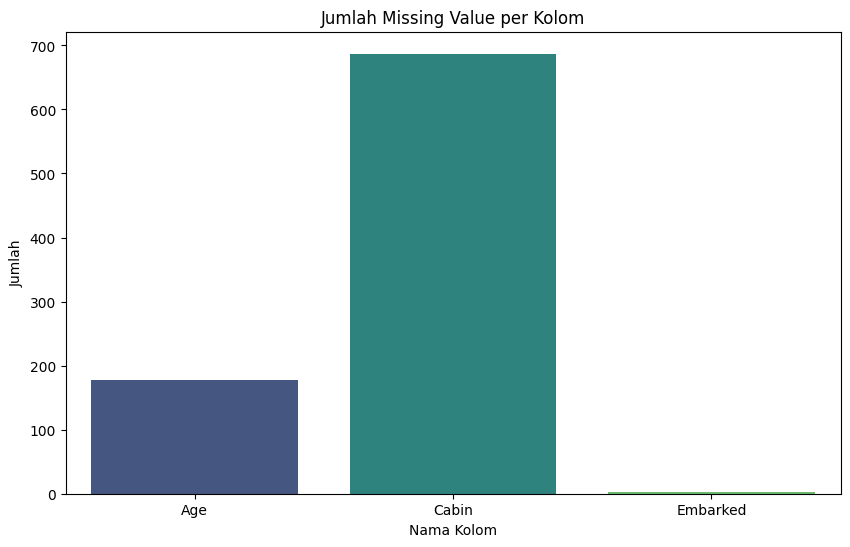

b. Heatmap pola missing value telah ditampilkan. Garis kuning menandakan data yang hilang.



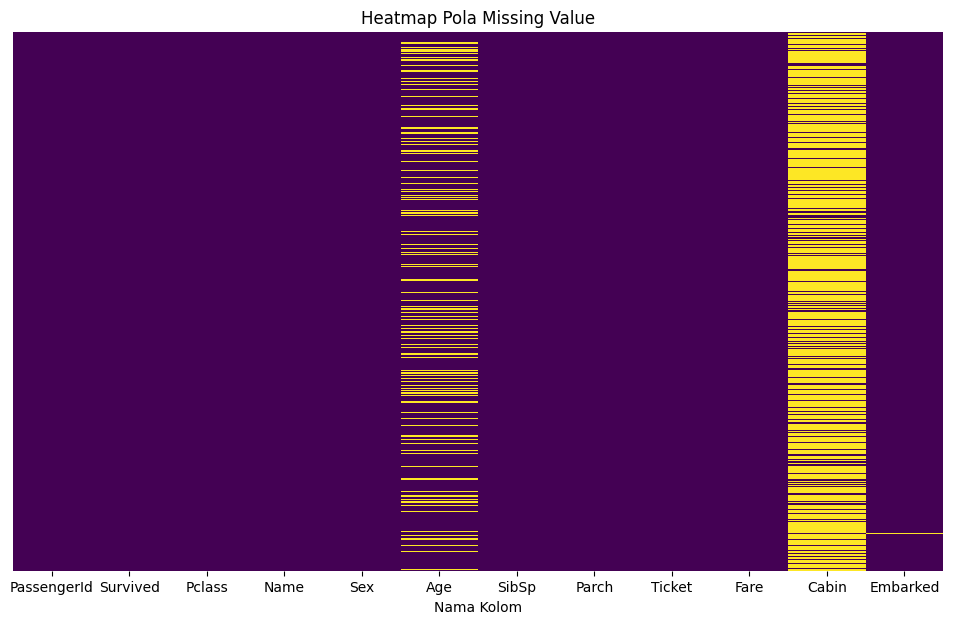

In [ ]:
# 2.2 Visualisasi Pola Missing Value
print("2.2 Visualisasi Pola Missing Value:")
print("-----------------------------------")

# Membuat bar chart untuk jumlah missing value.
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_count[missing_count > 0].index, y=missing_count[missing_count > 0].values, palette='viridis')
plt.title('Jumlah Missing Value per Kolom')
plt.ylabel('Jumlah')
plt.xlabel('Nama Kolom')
print("a. Bar chart jumlah missing value telah ditampilkan.\n")
plt.show()

# Membuat heatmap untuk melihat pola missing value secara keseluruhan.
# Area kuning menunjukkan data yang hilang (missing).
plt.figure(figsize=(12, 7))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Heatmap Pola Missing Value')
plt.xlabel('Nama Kolom')
print("b. Heatmap pola missing value telah ditampilkan. Garis kuning menandakan data yang hilang.\n")
plt.show()

#**Tahap 4 : Analisis Detail Pola Missing Value**
Setelah melihat gambaran besar, kita perlu menggali lebih dalam. Kode ini membantu kita menjawab, "Berapa banyak penumpang yang datanya tidak lengkap?" dengan menghitung jumlah baris yang memiliki setidaknya satu nilai kosong. Kita juga menampilkan lima contoh penumpang dengan data tidak lengkap untuk melihat seperti apa data tersebut secara konkret. Bagian ini diakhiri dengan ringkasan analisis pola yang menyimpulkan observasi dari tahap kuantitatif dan visual.

In [ ]:
# 2.3 Analisis Detail
print("2.3 Analisis Detail:")
print("--------------------")
# Mengidentifikasi baris-baris yang memiliki setidaknya satu missing value.
rows_with_missing = df[df.isnull().any(axis=1)]
print(f"a. Ditemukan {len(rows_with_missing)} baris yang mengandung setidaknya satu missing value.")
print("   Contoh 5 baris dengan missing value:")
print(rows_with_missing.head())
print("\n")

print("b. Analisis Pola:")
print("- Kolom 'Cabin' memiliki missing value paling banyak, menandakan data ini jarang tercatat.")
print("- Kolom 'Age' juga memiliki banyak missing value, namun polanya terlihat acak (tersebar).")
print("- Kolom 'Embarked' hanya memiliki 2 missing value, jumlahnya sangat sedikit.\n")

2.3 Analisis Detail:
--------------------
a. Ditemukan 708 baris yang mengandung setidaknya satu missing value.
   Contoh 5 baris dengan missing value:
   PassengerId  Survived  Pclass                            Name     Sex  \
0            1         0       3         Braund, Mr. Owen Harris    male   
2            3         1       3          Heikkinen, Miss. Laina  female   
4            5         0       3        Allen, Mr. William Henry    male   
5            6         0       3                Moran, Mr. James    male   
7            8         0       3  Palsson, Master. Gosta Leonard    male   

    Age  SibSp  Parch            Ticket     Fare Cabin Embarked  
0  22.0      1      0         A/5 21171   7.2500   NaN        S  
2  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S  
4  35.0      0      0            373450   8.0500   NaN        S  
5   NaN      0      0            330877   8.4583   NaN        Q  
7   2.0      3      1            349909  21.0750   NaN       

#**Tahap 5 : Evaluasi Dampak pada Statistik Deskriptif**
Sebelum "memperbaiki" data, kita harus memahami "kerusakan" yang ditimbulkannya. Kode ini menjalankan .describe() pada data asli. Outputnya secara jelas menunjukkan dampak dari data yang hilang: count untuk kolom Age adalah 714, bukan 891. Ini berarti semua perhitungan statistik untuk Age (mean, std, min, max) hanya didasarkan pada ~80% penumpang. Jika kelompok penumpang yang usianya hilang ini memiliki karakteristik yang berbeda, maka statistik yang kita lihat bisa menjadi bias dan tidak mewakili seluruh penumpang Titanic.

In [ ]:
# =============================================================================
# TAHAP 3: EVALUASI DAMPAK
# =============================================================================
print("=========================================")
print("TAHAP 3: EVALUASI DAMPAK MISSING VALUE")
print("=========================================\n")

# 3.1 Dampak pada Statistik Deskriptif
print("3.1 Dampak pada Statistik:")
print("--------------------------")
print("a. Statistik deskriptif untuk kolom numerik (SEBELUM penanganan):")
# Perhatikan bahwa 'Age' hanya menghitung 714 dari 891 penumpang.
print(df.describe())
print("\n")

print("b. Dampak utama:")
print("- Rata-rata (mean) pada kolom 'Age' hanya dihitung dari data yang ada, ini bisa menjadi bias.")
print("- Jika kita melakukan analisis yang melibatkan 'Age' atau 'Cabin', banyak baris akan terlewat.\n")

TAHAP 3: EVALUASI DAMPAK MISSING VALUE

3.1 Dampak pada Statistik:
--------------------------
a. Statistik deskriptif untuk kolom numerik (SEBELUM penanganan):
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000

#**Tahap 6: Evaluasi Dampak pada Ukuran Dataset**
Di sini kita mengevaluasi skenario terburuk menggunakan metode penanganan yang paling naif: Listwise Deletion (menghapus setiap baris yang memiliki data kosong). Kode ini menghitung dan menunjukkan konsekuensi drastis dari pendekatan ini. Kehilangan hampir 80% data ibarat mencoba memahami sebuah cerita dengan hanya membaca 2 dari 10 halaman. Model machine learning yang dilatih pada data sekecil ini akan sangat tidak andal. Analisis ini membuktikan mengapa kita harus mencari metode penanganan yang lebih baik.

In [ ]:
# 3.2 Dampak pada Jumlah Data Analisis
print("3.2 Dampak pada Jumlah Data yang Bisa Dianalisis:")
print("-------------------------------------------------")
# Menghitung jumlah baris yang akan tersisa jika kita menghapus semua baris dengan missing value.
rows_after_deletion = len(df.dropna())
rows_lost = len(df) - rows_after_deletion
percentage_lost = (rows_lost / len(df)) * 100

print(f"a. Jumlah data awal: {len(df)} baris.")
print(f"b. Jika semua baris dengan missing value dihapus (Listwise Deletion), data yang tersisa: {rows_after_deletion} baris.")
print(f"c. Jumlah data yang akan hilang: {rows_lost} baris ({percentage_lost:.2f}% dari total data).")
print("   Kehilangan lebih dari 80% data adalah dampak yang sangat signifikan!\n")

3.2 Dampak pada Jumlah Data yang Bisa Dianalisis:
-------------------------------------------------
a. Jumlah data awal: 891 baris.
b. Jika semua baris dengan missing value dihapus (Listwise Deletion), data yang tersisa: 183 baris.
c. Jumlah data yang akan hilang: 708 baris (79.46% dari total data).
   Kehilangan lebih dari 80% data adalah dampak yang sangat signifikan!



#**Tahap 7 : Implementasi Metode Penanganan - Listwise Deletion**
Ini adalah implementasi praktis dari Listwise Deletion. Kode ini mengambil salinan data asli, lalu fungsi .dropna() digunakan untuk menghapus semua baris yang memiliki setidaknya satu nilai NaN. Outputnya mengonfirmasi jumlah data yang tersisa sangat sedikit. Ini kita lakukan bukan untuk digunakan, tetapi sebagai bahan perbandingan nyata terhadap metode imputasi.

In [ ]:
# =============================================================================
# TAHAP 4: PENANGANAN MISSING VALUE
# =============================================================================
print("=========================================")
print("TAHAP 4: IMPLEMENTASI METODE PENANGANAN")
print("=========================================\n")

# Membuat salinan DataFrame untuk setiap metode agar data asli tidak berubah.
df_deleted = df.copy()
df_imputed = df.copy()

# --- Metode 1: Listwise Deletion ---
print("--- Metode 1: Listwise Deletion (Menghapus Baris) ---")
df_deleted.dropna(inplace=True)
print(f"Jumlah baris setelah penghapusan: {df_deleted.shape[0]}")
print(f"Jumlah missing value tersisa: {df_deleted.isnull().sum().sum()}\n")

TAHAP 4: IMPLEMENTASI METODE PENANGANAN

--- Metode 1: Listwise Deletion (Menghapus Baris) ---
Jumlah baris setelah penghapusan: 183
Jumlah missing value tersisa: 0



#**Tahap 8 : Implementasi Metode Penanganan - Imputation**
Ini adalah implementasi dari metode kedua yang lebih bijaksana, yaitu Imputasi (mengisi nilai). Kode ini menerapkan tiga strategi berbeda:
1.   Mean Imputation untuk Age: Mengisi usia yang hilang dengan rata-rata. Ini adalah metode cepat untuk data numerik, meskipun dapat mengurangi variasi data.
2.   Mode Imputation untuk Embarked: Mengisi pelabuhan yang hilang dengan yang paling sering muncul. Ini adalah standar untuk data kategorikal.
3.   Random Sample Imputation untuk Cabin: Ini adalah metode yang menarik. Daripada menghapus kolom Cabin, kita mengisinya dengan memilih secara acak dari nilai-nilai kabin yang sudah ada. Keuntungannya adalah kita mempertahankan distribusi asli data kabin dan menjaga kolom tersebut tetap ada untuk analisis lebih lanjut (misalnya, membuat fitur Deck). Kode ini juga secara eksplisit menampilkan tabel penjabaran lengkap untuk semua 687 nilai baru.

In [ ]:
# --- Metode 2 & 3 digabung: Imputation (Mengisi Nilai) ---
# [PERBAIKAN] Selalu mulai dengan salinan baru dari data asli untuk memastikan kode bisa dijalankan berulang kali.
df_imputed = df.copy()

print("--- Metode 2 & 3: Imputation (Mean, Mode, dan Random Sample) ---")

# Mengisi 'Age' dengan rata-rata (Mean Imputation)
mean_age = df_imputed['Age'].mean()
df_imputed['Age'] = df_imputed['Age'].fillna(mean_age)
print(f"Missing value di 'Age' diisi dengan nilai rata-rata: {mean_age:.2f}")

# Mengisi 'Embarked' dengan modus (Mode Imputation)
mode_embarked = df_imputed['Embarked'].mode()[0]
df_imputed['Embarked'] = df_imputed['Embarked'].fillna(mode_embarked)
print(f"Missing value di 'Embarked' diisi dengan nilai modus: '{mode_embarked}'")

# --- Penjabaran untuk 'Cabin' ---
# 1. Simpan dulu indeks baris yang cabin-nya kosong dari salinan data yang masih bersih
original_missing_cabin_indices = df_imputed[df_imputed['Cabin'].isnull()].index

# 2. Lakukan proses Random Sample Imputation
cabin_not_null = df_imputed['Cabin'].dropna()
missing_cabin_count = df_imputed['Cabin'].isnull().sum()
random_cabin_sample = np.random.choice(cabin_not_null, size=missing_cabin_count)
df_imputed.loc[df_imputed['Cabin'].isnull(), 'Cabin'] = random_cabin_sample
print(f"Missing value di 'Cabin' diisi menggunakan metode Random Sample Imputation.")

# 3. Buat dan tampilkan tabel penjabaran hasil imputasi 'Cabin'
# Tabel ini menggunakan indeks yang kita simpan di awal untuk mengambil nilai baru yang sudah diisi
cabin_replacements = pd.DataFrame({
    'PassengerId': original_missing_cabin_indices + 1,
    'New_Cabin_Value': df_imputed.loc[original_missing_cabin_indices, 'Cabin']
})

# Atur opsi agar pandas menampilkan semua baris
pd.set_option('display.max_rows', None)

print("\n--- Penjabaran Lengkap Hasil Imputasi Acak untuk Kolom 'Cabin' ---")
print(cabin_replacements)

# Kembalikan opsi ke pengaturan awal
pd.reset_option('display.max_rows')

print(f"\nJumlah missing value tersisa setelah imputasi: {df_imputed.isnull().sum().sum()}\n")

--- Metode 2 & 3: Imputation (Mean, Mode, dan Random Sample) ---
Missing value di 'Age' diisi dengan nilai rata-rata: 29.70
Missing value di 'Embarked' diisi dengan nilai modus: 'S'
Missing value di 'Cabin' diisi menggunakan metode Random Sample Imputation.

--- Penjabaran Lengkap Hasil Imputasi Acak untuk Kolom 'Cabin' ---
     PassengerId  New_Cabin_Value
0              1              E31
2              3               C2
4              5                D
5              6               E8
7              8              E31
8              9              C68
9             10               F2
12            13              D45
13            14              B39
14            15              C91
15            16              F38
16            17              D33
17            18          B96 B98
18            19               F4
19            20              B20
20            21             E101
22            23              D48
24            25               B5
25            26            

#**Tahap 9 : Perbandingan Hasil Akhir**
Setelah kedua metode diterapkan, penting untuk membandingkan hasilnya secara langsung. Kode ini membuat sebuah tabel ringkasan yang berfungsi sebagai "papan skor". Tabel ini membandingkan Data Asli, Listwise Deletion, dan Imputation berdasarkan metrik kunci: jumlah baris yang tersisa, jumlah total nilai kosong, dan Complete Rate (%) yang menunjukkan persentase data yang berhasil dipertahankan. Tabel ini membuat keputusan menjadi sangat jelas dan berdasarkan data.

In [ ]:
# --- Perbandingan Hasil ---
print("--- Perbandingan Hasil Akhir ---")
# Membuat ringkasan untuk perbandingan
summary = {
    'Metode': ['Data Asli', 'Listwise Deletion', 'Imputation'],
    'Jumlah Baris': [len(df), len(df_deleted), len(df_imputed)],
    'Total Missing Values': [total_missing, df_deleted.isnull().sum().sum(), df_imputed.isnull().sum().sum()]
}
summary_df = pd.DataFrame(summary)
summary_df['Complete Rate (%)'] = ((summary_df['Jumlah Baris'] / len(df)) * 100).round(2)
print(summary_df)
print("\n")

--- Perbandingan Hasil Akhir ---
              Metode  Jumlah Baris  Total Missing Values  Complete Rate (%)
0          Data Asli           891                   866             100.00
1  Listwise Deletion           183                     0              20.54
2         Imputation           891                     0             100.00




#**Tahap 10 : Keputusan, validasi, dan penyimpanan**
Ini adalah tahap terakhir dari proses pembersihan data. Bagian ini merangkum rekomendasi metode terbaik berdasarkan perbandingan sebelumnya. Kemudian, kode akan memvalidasi data yang telah dibersihkan untuk memastikan tidak ada lagi nilai kosong, dan terakhir menyimpannya ke dalam file CSV baru (titanic_cleaned.csv) untuk digunakan pada analisis selanjutnya.
1. Rekomendasi: Berdasarkan tabel perbandingan, bagian ini menyajikan kesimpulan logis: metode Imputasi adalah yang terbaik karena mempertahankan 100% data. Rekomendasi ini juga menjelaskan pilihan spesifik untuk setiap kolom.
2. Validasi: Sebelum selesai, kita harus melakukan satu pengecekan terakhir. Kode validasi ini menjalankan .info() dan .isnull().sum() pada data yang sudah diimputasi (df_imputed) untuk membuktikan secara definitif bahwa semua kolom sekarang memiliki 891 entri dan tidak ada satupun nilai kosong yang tersisa.
3. Penyimpanan: Sebagai praktik terbaik, data yang sudah bersih disimpan ke file baru (titanic_cleaned.csv). Ini menghemat waktu kita di masa depan, karena kita tidak perlu mengulangi semua langkah pembersihan ini lagi dan bisa langsung memulai analisis atau pemodelan.

In [ ]:
# =============================================================================
# TAHAP 5: KEPUTUSAN & VALIDASI
# =============================================================================
print("=========================================")
print("TAHAP 5: KEPUTUSAN & VALIDASI")
print("=========================================\n")

# 5.1 Rekomendasi & Finalisasi
print("5.1 Rekomendasi:")
print("----------------")
print("- Listwise Deletion menyebabkan kehilangan data yang sangat besar (lebih dari 80%), sehingga tidak direkomendasikan.")
print("- Metode Imputation adalah pilihan terbaik karena mempertahankan semua baris data (100% Complete Rate).")
print("- Untuk 'Cabin', metode Random Sample Imputation dipilih untuk mempertahankan kolom tersebut.")
print("  Meskipun data yang diisi bersifat artifisial, ini memungkinkan kita untuk melakukan feature engineering (misal: membuat fitur 'Deck').")
print("\n=> Metode yang dipilih adalah IMPUTASI (Mean untuk 'Age', Mode untuk 'Embarked', dan Random Sample untuk 'Cabin').\n")

# 5.2 Validasi Hasil Akhir
print("5.2 Validasi Data Bersih (Hasil Imputasi):")
print("------------------------------------------")
print("a. Cek ulang informasi data setelah dibersihkan:")
df_imputed.info()
print("\n")

print("b. Cek ulang jumlah missing value:")
print(df_imputed.isnull().sum())
print("\nData akhir sudah bersih dari missing value.\n")

# 5.3 Simpan Data Bersih
# Menyimpan hasil ke file CSV baru.
df_imputed.to_csv('titanic_cleaned.csv', index=False)
print("5.3 Data yang sudah bersih telah disimpan ke file 'titanic_cleaned.csv'.")

TAHAP 5: KEPUTUSAN & VALIDASI

5.1 Rekomendasi:
----------------
- Listwise Deletion menyebabkan kehilangan data yang sangat besar (lebih dari 80%), sehingga tidak direkomendasikan.
- Metode Imputation adalah pilihan terbaik karena mempertahankan semua baris data (100% Complete Rate).
- Untuk 'Cabin', metode Random Sample Imputation dipilih untuk mempertahankan kolom tersebut.
  Meskipun data yang diisi bersifat artifisial, ini memungkinkan kita untuk melakukan feature engineering (misal: membuat fitur 'Deck').

=> Metode yang dipilih adalah IMPUTASI (Mean untuk 'Age', Mode untuk 'Embarked', dan Random Sample untuk 'Cabin').

5.2 Validasi Data Bersih (Hasil Imputasi):
------------------------------------------
a. Cek ulang informasi data setelah dibersihkan:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
